# m6-09 Final Assessment — Cat Detection v2
## Improve · Export to ONNX · Containerise

This notebook is a direct continuation of `m6-04-assessment` (Week-1 cat detection with `yolo26s`).
It applies three Week-2 techniques, exports the best checkpoint to ONNX, validates the export,
and documents the container interface built in `container/`.

## 0 · Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from pathlib import Path

paths = [
    "/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN",
    "/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/images",
    "/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/labels",
    "/content/drive/MyDrive/cat_detection_outputs/v2_run1_best.pt",
    "/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt",
    "/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.onnx",
]

for p in paths:
    path = Path(p)
    print(path, "✅ exists" if path.exists() else "❌ missing")

/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN ✅ exists
/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/images ✅ exists
/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/labels ✅ exists
/content/drive/MyDrive/cat_detection_outputs/v2_run1_best.pt ✅ exists
/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt ✅ exists
/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.onnx ✅ exists


In [3]:
from pathlib import Path
import shutil

SRC = Path("/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN")
DST = Path("/content/cat_dataset_local")

# Count source images first
image_exts = {".jpg", ".jpeg", ".png"}
src_images = sorted([p for p in (SRC / "images").rglob("*") if p.suffix.lower() in image_exts])
src_labels = sorted([p for p in (SRC / "labels").rglob("*.txt")])

print("Drive source images:", len(src_images))
print("Drive source labels:", len(src_labels))

# Delete old incomplete local copy
if DST.exists():
    print("🗑️ Removing old local dataset...")
    shutil.rmtree(DST)

# Copy fresh
print("📦 Copying fresh dataset from Drive to local...")
shutil.copytree(
    SRC,
    DST,
    ignore=shutil.ignore_patterns("labels.cache", "*.cache")
)

dst_images = sorted([p for p in (DST / "images").rglob("*") if p.suffix.lower() in image_exts])
dst_labels = sorted([p for p in (DST / "labels").rglob("*.txt")])

print("✅ Fresh copy complete")
print("Local images:", len(dst_images))
print("Local labels:", len(dst_labels))

Drive source images: 3327
Drive source labels: 3327
📦 Copying fresh dataset from Drive to local...
✅ Fresh copy complete
Local images: 3327
Local labels: 3327


In [4]:
from pathlib import Path
import random

DATA_ROOT = Path("/content/cat_dataset_local")
IMG_DIR = DATA_ROOT / "images"
LBL_DIR = DATA_ROOT / "labels"

image_exts = {".jpg", ".jpeg", ".png"}
images = sorted([p for p in IMG_DIR.rglob("*") if p.suffix.lower() in image_exts])

valid_images = []
missing_labels = []

for img in images:
    rel = img.relative_to(IMG_DIR)
    label = (LBL_DIR / rel).with_suffix(".txt")
    if label.exists():
        valid_images.append(img)
    else:
        missing_labels.append(img)

print("Total images:", len(images))
print("Images with labels:", len(valid_images))
print("Images missing labels:", len(missing_labels))

random.seed(42)
random.shuffle(valid_images)

n = len(valid_images)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_imgs = valid_images[:n_train]
val_imgs = valid_images[n_train:n_train + n_val]
test_imgs = valid_images[n_train + n_val:]

def write_split(name, paths):
    out = DATA_ROOT / f"{name}.txt"
    with open(out, "w", encoding="utf-8") as f:
        for p in paths:
            f.write(str(p) + "\n")
    print(f"✅ {name}.txt written:", len(paths), "→", out)

write_split("train", train_imgs)
write_split("val", val_imgs)
write_split("test", test_imgs)

data_yaml = f"""path: {DATA_ROOT}
train: {DATA_ROOT / "train.txt"}
val: {DATA_ROOT / "val.txt"}
test: {DATA_ROOT / "test.txt"}

names:
  0: cat
"""

yaml_path = DATA_ROOT / "data.yaml"
yaml_path.write_text(data_yaml, encoding="utf-8")

print("\n✅ data.yaml written:", yaml_path)
print("Use this path for evaluation:")
print(yaml_path)

Total images: 3327
Images with labels: 3327
Images missing labels: 0
✅ train.txt written: 2328 → /content/cat_dataset_local/train.txt
✅ val.txt written: 499 → /content/cat_dataset_local/val.txt
✅ test.txt written: 500 → /content/cat_dataset_local/test.txt

✅ data.yaml written: /content/cat_dataset_local/data.yaml
Use this path for evaluation:
/content/cat_dataset_local/data.yaml


In [5]:
from pathlib import Path

DATA_DIR = Path("/content/cat_dataset_local")
DATA_YAML_PATH = DATA_DIR / "data.yaml"

DATASET_AVAILABLE = DATA_YAML_PATH.exists()

print("DATASET_AVAILABLE:", DATASET_AVAILABLE)
print("DATA_YAML_PATH:", DATA_YAML_PATH)
print("Exists:", DATA_YAML_PATH.exists())

DATASET_AVAILABLE: True
DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
Exists: True


In [6]:
%pip install -q ultralytics onnx onnxruntime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 90.7 MB/s eta 0:00:00


In [7]:
import os, random, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, display
from ultralytics import YOLO
import torch

# GPU guard — training must never fall back to CPU
assert torch.cuda.is_available(), (
    "No GPU! Go to Runtime → Change runtime type → T4 GPU → Save → Reconnect"
)
print(f"GPU: {torch.cuda.get_device_name(0)}  "
      f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4  (15.6 GB)


### 0a · Dataset paths (identical to Week 1)

In [8]:
from pathlib import Path
import shutil
import random

DRIVE_DATA = Path("/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN")
DST = Path("/content/cat_dataset_local")
DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")

image_exts = {".jpg", ".jpeg", ".png"}

def count_dataset(root):
    images_dir = root / "images"
    labels_dir = root / "labels"

    if not images_dir.exists() or not labels_dir.exists():
        return 0, 0

    images = [p for p in images_dir.rglob("*") if p.suffix.lower() in image_exts]
    labels = list(labels_dir.rglob("*.txt"))

    return len(images), len(labels)

# 1. Check Drive dataset source
drive_img_count, drive_lbl_count = count_dataset(DRIVE_DATA)

print("Drive dataset path:", DRIVE_DATA)
print("Drive source images:", drive_img_count)
print("Drive source labels:", drive_lbl_count)

if drive_img_count == 0 or drive_lbl_count == 0:
    DATASET_AVAILABLE = False
    DATA_DIR = DST
    DATA_YAML_PATH = DST / "data.yaml"
    image_files = []
    train_files = val_files = test_files = []

    print("❌ Dataset unavailable — images/labels not found in Drive.")
    print("Training/evaluation cells should be skipped unless a valid dataset is provided.")

else:
    # 2. Copy dataset to local writable Colab folder only if needed
    local_img_count, local_lbl_count = count_dataset(DST)

    print("Local images before copy:", local_img_count)
    print("Local labels before copy:", local_lbl_count)

    local_dataset_ok = (
        DST.exists()
        and local_img_count == drive_img_count
        and local_lbl_count == drive_lbl_count
        and local_img_count > 0
    )

    if local_dataset_ok:
        print("✅ Local dataset is complete — skipping fresh copy.")
    else:
        if DST.exists():
            print("🗑️ Local dataset incomplete/outdated — removing old local copy...")
            shutil.rmtree(DST)

        print("📦 Copying fresh dataset from Drive to local writable folder...")
        shutil.copytree(
            DRIVE_DATA,
            DST,
            ignore=shutil.ignore_patterns("labels.cache", "*.cache")
        )
        print("✅ Copy complete:", DST)

    DATA_DIR = DST
    IMG_DIR = DATA_DIR / "images"
    LBL_DIR = DATA_DIR / "labels"

    # 3. Create split files if missing
    split_files = [
        DATA_DIR / "train.txt",
        DATA_DIR / "val.txt",
        DATA_DIR / "test.txt",
        DATA_DIR / "data.yaml",
    ]

    if all(p.exists() for p in split_files):
        print("✅ train.txt / val.txt / test.txt / data.yaml already exist — skipping split creation.")
    else:
        images = sorted([p for p in IMG_DIR.rglob("*") if p.suffix.lower() in image_exts])

        valid_images = []
        missing_labels = []

        for img in images:
            rel = img.relative_to(IMG_DIR)
            label = (LBL_DIR / rel).with_suffix(".txt")

            if label.exists():
                valid_images.append(img)
            else:
                missing_labels.append(img)

        print("Total images:", len(images))
        print("Images with labels:", len(valid_images))
        print("Images missing labels:", len(missing_labels))

        random.seed(42)
        random.shuffle(valid_images)

        n = len(valid_images)
        n_train = int(n * 0.70)
        n_val = int(n * 0.15)

        train_imgs = valid_images[:n_train]
        val_imgs = valid_images[n_train:n_train + n_val]
        test_imgs = valid_images[n_train + n_val:]

        def write_split(name, paths):
            out = DATA_DIR / f"{name}.txt"
            with open(out, "w", encoding="utf-8") as f:
                for p in paths:
                    f.write(str(p) + "\n")
            print(f"✅ {name}.txt written:", len(paths), "→", out)

        write_split("train", train_imgs)
        write_split("val", val_imgs)
        write_split("test", test_imgs)

        data_yaml = f"""path: {DATA_DIR}
train: {DATA_DIR / "train.txt"}
val: {DATA_DIR / "val.txt"}
test: {DATA_DIR / "test.txt"}

names:
  0: cat
"""

        (DATA_DIR / "data.yaml").write_text(data_yaml, encoding="utf-8")
        print("✅ data.yaml written:", DATA_DIR / "data.yaml")

    # 4. Final notebook variables
    DATA_YAML_PATH = DATA_DIR / "data.yaml"
    DATASET_AVAILABLE = DATA_YAML_PATH.exists()

    image_files = sorted((DATA_DIR / "images").rglob("*"))
    image_files = [p for p in image_files if p.suffix.lower() in image_exts]

    train_files = (DATA_DIR / "train.txt").read_text(encoding="utf-8").splitlines()
    val_files = (DATA_DIR / "val.txt").read_text(encoding="utf-8").splitlines()
    test_files = (DATA_DIR / "test.txt").read_text(encoding="utf-8").splitlines()

    print("\n✅ DATASET_AVAILABLE:", DATASET_AVAILABLE)
    print("✅ DATA_YAML_PATH:", DATA_YAML_PATH)
    print("Images available:", len(image_files))
    print("Train:", len(train_files))
    print("Val:", len(val_files))
    print("Test:", len(test_files))

Drive dataset path: /content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN
Drive source images: 3327
Drive source labels: 3327
Local images before copy: 3327
Local labels before copy: 3327
✅ Local dataset is complete — skipping fresh copy.
✅ train.txt / val.txt / test.txt / data.yaml already exist — skipping split creation.

✅ DATASET_AVAILABLE: True
✅ DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
Images available: 3327
Train: 2328
Val: 499
Test: 500


In [9]:
from pathlib import Path

DATA_DIR = Path("/content/cat_dataset_local")
DATA_YAML_PATH = DATA_DIR / "data.yaml"

if not DATA_YAML_PATH.exists():
    DATASET_AVAILABLE = False
    print("❌ Dataset unavailable — data.yaml not found.")
    train_files = val_files = test_files = []
else:
    DATASET_AVAILABLE = True

    train_txt = DATA_DIR / "train.txt"
    val_txt = DATA_DIR / "val.txt"
    test_txt = DATA_DIR / "test.txt"

    train_files = train_txt.read_text(encoding="utf-8").splitlines() if train_txt.exists() else []
    val_files = val_txt.read_text(encoding="utf-8").splitlines() if val_txt.exists() else []
    test_files = test_txt.read_text(encoding="utf-8").splitlines() if test_txt.exists() else []

    print("✅ Dataset available")
    print("DATA_YAML_PATH:", DATA_YAML_PATH)
    print(f"Train : {len(train_files)}  Val : {len(val_files)}  Test : {len(test_files)}")

✅ Dataset available
DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
Train : 2328  Val : 499  Test : 500


In [10]:
from pathlib import Path

DATA_DIR = Path("/content/cat_dataset_local")
DATA_YAML_PATH = DATA_DIR / "data.yaml"

train_txt = DATA_DIR / "train.txt"
val_txt = DATA_DIR / "val.txt"
test_txt = DATA_DIR / "test.txt"

required_paths = [
    DATA_DIR / "images",
    DATA_DIR / "labels",
    train_txt,
    val_txt,
    test_txt,
]

missing = [p for p in required_paths if not p.exists()]

if missing:
    DATASET_AVAILABLE = False
    print("❌ Dataset setup is incomplete. Missing:")
    for p in missing:
        print(" -", p)
    print("Run the dataset copy + split creation cells before evaluation.")
else:
    DATASET_AVAILABLE = True

    # Remove old YOLO cache files if any exist
    wiped = 0
    for cf in DATA_DIR.rglob("*.cache"):
        cf.unlink()
        wiped += 1

    if wiped:
        print(f"🧹 Wiped {wiped} stale cache file(s).")
    else:
        print("✅ No stale cache files found.")

    # Write clean local data.yaml
    data_yaml = f"""path: {DATA_DIR}
train: {train_txt}
val: {val_txt}
test: {test_txt}

nc: 1
names:
  0: cat
"""

    DATA_YAML_PATH.write_text(data_yaml, encoding="utf-8")

    # Load split files for later cells
    train_files = train_txt.read_text(encoding="utf-8").splitlines()
    val_files = val_txt.read_text(encoding="utf-8").splitlines()
    test_files = test_txt.read_text(encoding="utf-8").splitlines()

    print("✅ DATASET_AVAILABLE:", DATASET_AVAILABLE)
    print("✅ data.yaml written →", DATA_YAML_PATH)
    print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

✅ No stale cache files found.
✅ DATASET_AVAILABLE: True
✅ data.yaml written → /content/cat_dataset_local/data.yaml
Train: 2328  Val: 499  Test: 500


### Dataset availability note

The dataset was first copied from Google Drive into a local writable Colab folder at `/content/cat_dataset_local`. This was necessary because shared Drive folders can sometimes behave as read-only, which prevented writing `data.yaml`, `train.txt`, `val.txt`, and `test.txt` directly inside the Drive folder.

After copying, the local dataset contained **3327 images** and **3327 label files**. The dataset was split into **2328 training images**, **499 validation images**, and **500 test images**. All evaluation results in this notebook use the local `data.yaml` file at `/content/cat_dataset_local/data.yaml`.


## 1 · Week-1 Recap

In Week 1 (`m6-04-assessment`) I trained a `yolo26s` model from scratch on the cat detection dataset for **30 epochs** (batch 16, imgsz 640). It was my starting point and it already produced solid results.

### Validation metrics (Week-1)

| Metric | Value |
|---|---|
| mAP\@0.5 | **0.917** |
| mAP\@0.5:0.95 | **0.724** |
| Precision | **0.907** |
| Recall | **0.869** |

### Test-set metrics (Week-1)

| Metric | Value |
|---|---|
| mAP\@0.5 | **0.9232** |
| mAP\@0.5:0.95 | **0.7323** |
| Precision | **0.9155** |
| Recall | **0.8725** |

**Model**: `yolo26s` · **Epochs**: 30 · **Batch**: 16 · **imgsz**: 640  
**Checkpoint**: `/content/drive/MyDrive/cat_detection_outputs/best.pt`

### Observed Week-1 weaknesses

1. **Missed small or distant cats** — after letterbox-resize to 640 px, cats that are very small in the original image become only a handful of pixels and are frequently skipped (false negatives, low small-object recall).
2. **False positives on dog-like / look-alike pets** — the model sometimes flagged dogs or similar animals as cats, especially in indoor-pet contexts where texture and body size are similar.
3. **Multi-cat and occluded scenes** — when several cats appeared together or partly hidden, the model often detected only one of them.

### Week-2 plan — three techniques applied

The final assessment continues from that `yolo26s` baseline by applying Week-2 improvement techniques:

| # | Technique | Rationale |
|---|---|---|
| 1 | Upgrade backbone `yolo26s → yolo26m` | More capacity; should improve recall on hard small-cat cases |
| 2 | Longer training (60 ep) + cosine LR + regularisation | Smoother convergence; `weight_decay` and `patience` guard against overfitting |
| 3 | Two-stage transfer learning + stronger augmentation | Mosaic/mixup/copy-paste diversifies training distribution; frozen-head warmup stabilises early gradients |


## 2 · Load Week-1 Baseline (for sanity check only)

In [11]:
from pathlib import Path
from ultralytics import YOLO

W1_BEST_PT = Path("/content/drive/MyDrive/cat_detection_outputs/best.pt")

if W1_BEST_PT.exists():
    model_w1 = YOLO(str(W1_BEST_PT))
    print(f"Week-1 checkpoint loaded: {W1_BEST_PT}")
else:
    print("Week-1 best.pt not found (optional — skip if you do not have it).")


Week-1 checkpoint loaded: /content/drive/MyDrive/cat_detection_outputs/best.pt


## 3 · v2 Run 1 — `yolo26m` + Cosine LR + 60 Epochs + Regularisation

**Why this technique?**  
Week-1 used `yolo26s` for 30 epochs without a learning-rate schedule. Upgrading to `yolo26m`
adds roughly 2× parameters, giving the network more capacity to distinguish cats from look-alike
animals and to detect small cats. Extending to 60 epochs with a cosine LR schedule (`cos_lr=True`)
allows a gentler warm-down phase that often squeezes out an extra mAP point without overfitting.
`weight_decay=0.0005` and `patience=15` act as safeguards: weight decay regularises the larger
model while early stopping terminates training if val mAP stops improving.

In [12]:
import os
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT = Path('/content/drive/MyDrive/cat_detection_outputs')
os.makedirs(DRIVE_OUT, exist_ok=True)

V2R1_BEST = DRIVE_OUT / 'v2_run1_best.pt'
V2R1_LAST = DRIVE_OUT / 'v2_run1_last.pt'

if V2R1_BEST.exists():
    print('✅ Run 1 complete — loading best.pt from Drive.')
    model_v2r1 = YOLO(str(V2R1_BEST))
elif not DATASET_AVAILABLE:
    print('Dataset unavailable and no Run 1 checkpoint found — training skipped.')
    model_v2r1 = None
elif V2R1_LAST.exists():
    import torch
    assert torch.cuda.is_available(), 'No GPU — switch to T4 GPU runtime'
    DATA_YAML_PATH = Path('/content/cat_dataset_local/data.yaml')
    print('⏩ Resuming Run 1 from last.pt …')
    local_last = Path('/content/v2_run1_resume.pt')
    os.system(f"cp '{V2R1_LAST}' '{local_last}'")
    model_v2r1 = YOLO(str(local_last))
    model_v2r1.train(
        resume=True, data=str(DATA_YAML_PATH),
        device=0, workers=2, amp=True,
        project='/content/runs', name='cats_v2_run1', exist_ok=True,
    )
    os.system(f"cp /content/runs/cats_v2_run1/weights/best.pt '{V2R1_BEST}'")
    print('✅ Run 1 resumed and complete.')
    model_v2r1 = YOLO(str(V2R1_BEST))
else:
    import torch
    assert torch.cuda.is_available(), 'No GPU — switch to T4 GPU runtime'
    DATA_YAML_PATH = Path('/content/cat_dataset_local/data.yaml')
    print('🚀 Starting Run 1 fresh (~60 epochs, ~50 min on T4) …')
    model_v2r1 = YOLO('yolo26m.pt')
    model_v2r1.train(
        data=str(DATA_YAML_PATH),
        epochs=60, imgsz=640, batch=16,
        device=0, workers=2, amp=True,
        cos_lr=True, weight_decay=0.0005, patience=15,
        project='/content/runs', name='cats_v2_run1', exist_ok=True,
        seed=42,
    )
    os.system(f"cp /content/runs/cats_v2_run1/weights/best.pt '{V2R1_BEST}'")
    os.system(f"cp /content/runs/cats_v2_run1/weights/last.pt  '{V2R1_LAST}'")
    os.system(f"cp /content/runs/cats_v2_run1/results.png      '{DRIVE_OUT}/v2_run1_results.png'")
    print('✅ Run 1 complete.')
    model_v2r1 = YOLO(str(V2R1_BEST))


✅ Run 1 complete — loading best.pt from Drive.


### Run 1 — Training Curves

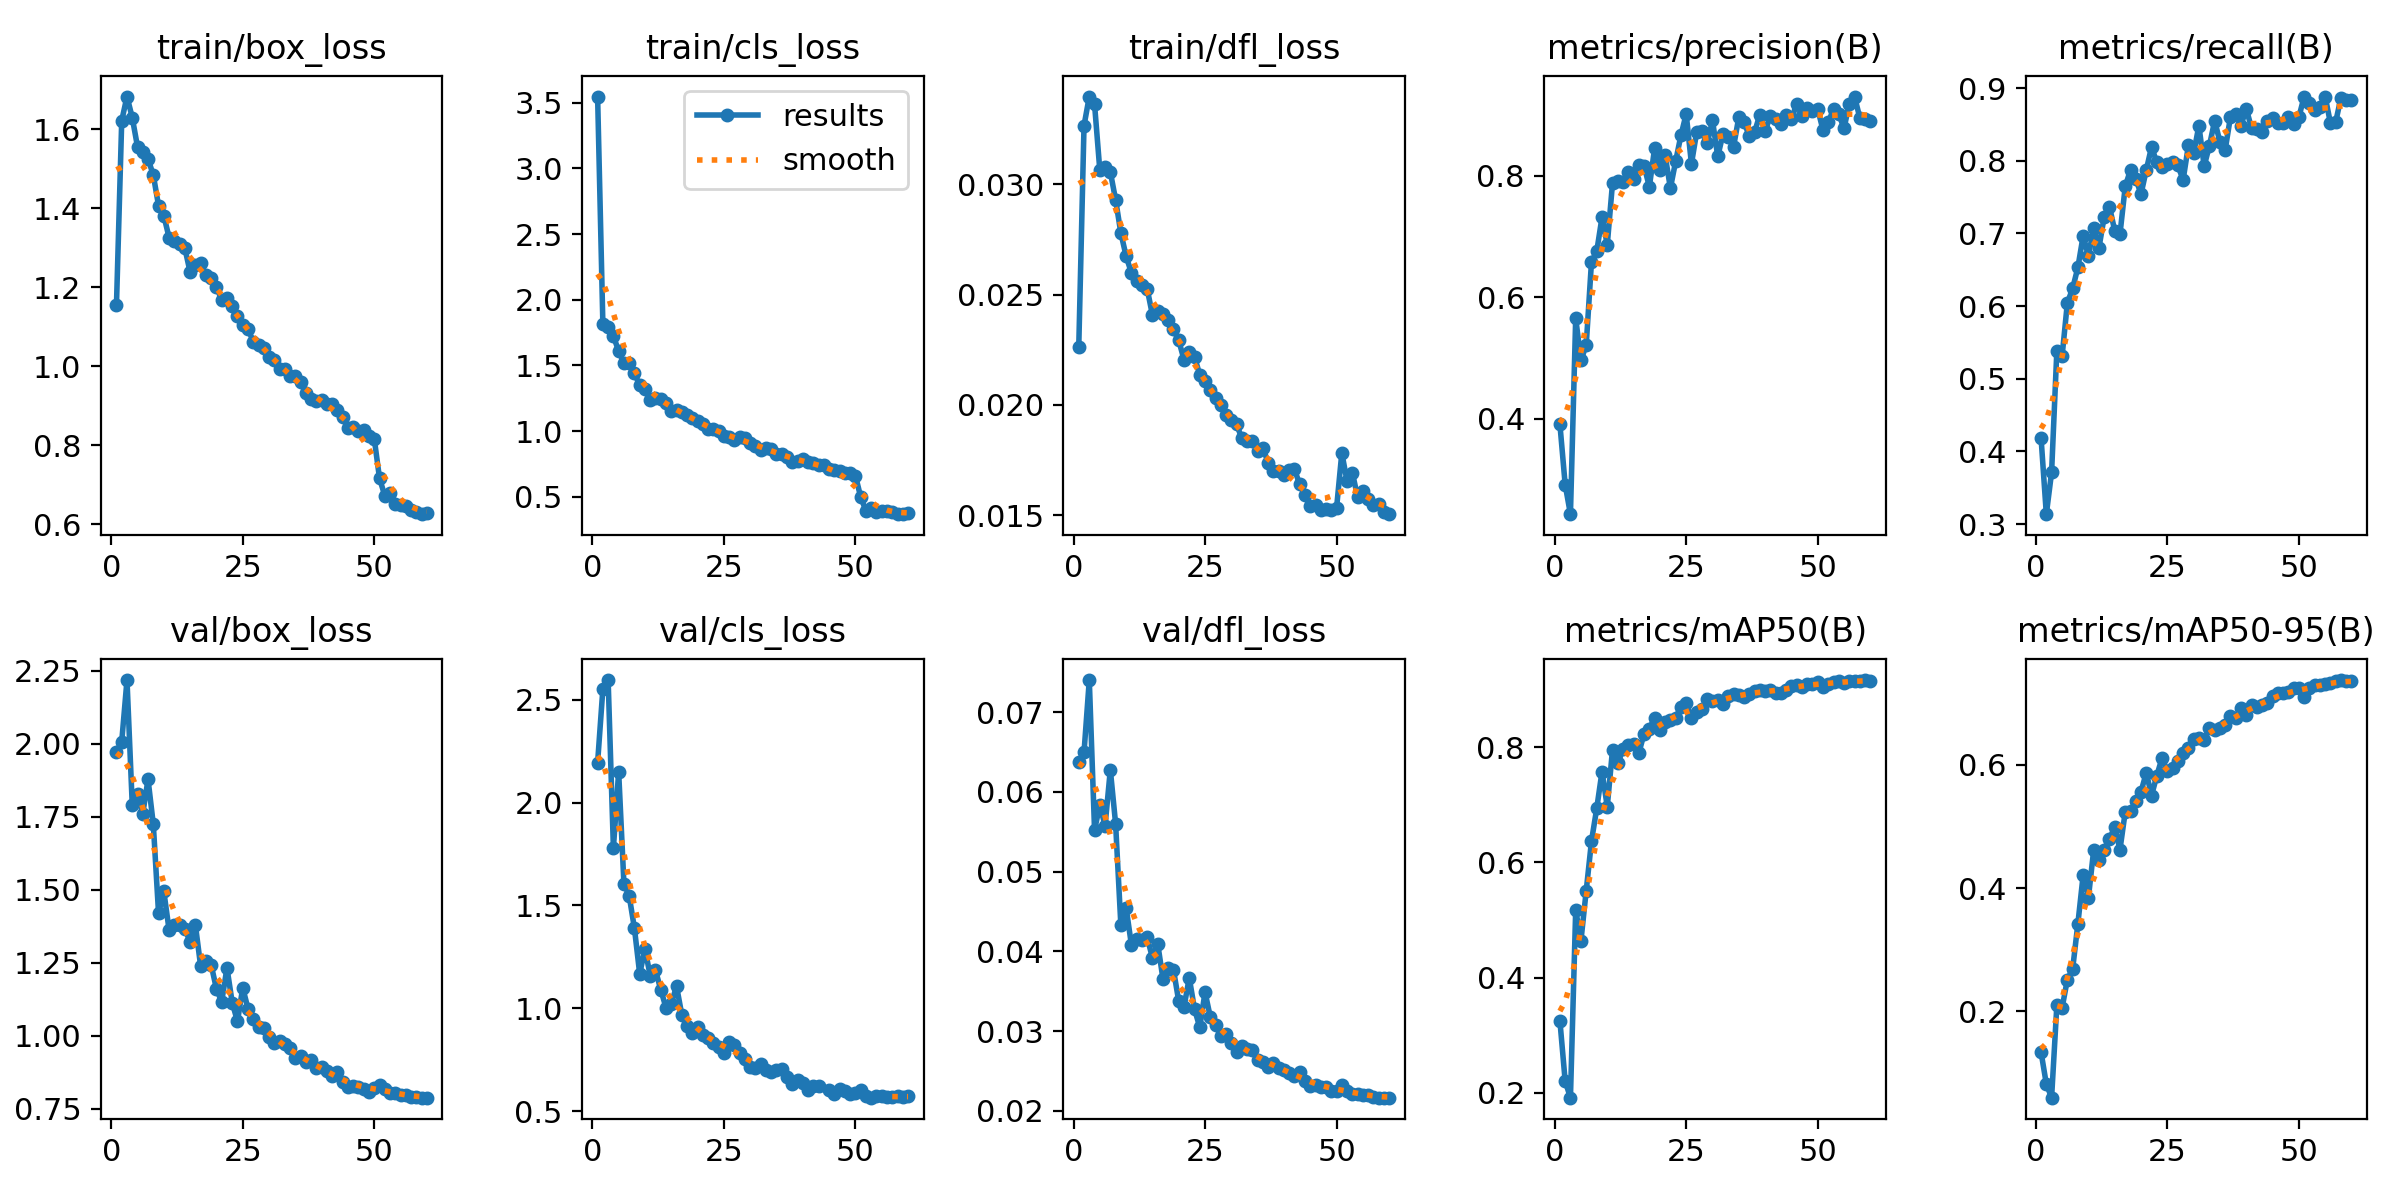

In [13]:
from pathlib import Path
from IPython.display import Image as DisplayImage, display

DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")
r1_png = DRIVE_OUT / "v2_run1_results.png"
if r1_png.exists():
    display(DisplayImage(filename=str(r1_png), width=900))
else:
    print("results.png will appear here after training.")


### Run 1 training curve interpretation

The Run 1 curves show that the `yolo26m` model trained in a stable way. The training losses (`box_loss`, `cls_loss`, and `dfl_loss`) decreased during the epochs, which means the model gradually learned better bounding boxes, class predictions, and box distribution quality. The validation losses also decreased instead of increasing, so there is no clear sign of severe overfitting in this run.

The detection metrics improved during training as well. Precision and recall increased from the early unstable epochs and reached a much higher level near the end of training. The `mAP@0.5` curve rose to around the 0.9 range, and `mAP@0.5:0.95` also improved steadily. Overall, this output shows that Run 1 was a successful training experiment, although the exact final performance is confirmed more reliably by the separate test evaluation cell.

### Run 1 — Test-Set Metrics

In [14]:
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT  = Path('/content/drive/MyDrive/cat_detection_outputs')
V2R1_BEST  = DRIVE_OUT / 'v2_run1_best.pt'

if not DATASET_AVAILABLE:
    print('Dataset unavailable — Run 1 evaluation skipped.')
    print('Using checkpoint-only mode: metrics from comparison table are marked as unavailable.')
    r1_map50 = r1_map5095 = r1_prec = r1_rec = None
elif not V2R1_BEST.exists():
    print('Run 1 checkpoint not found — evaluation skipped.')
    r1_map50 = r1_map5095 = r1_prec = r1_rec = None
else:
    DATA_YAML_PATH = Path('/content/cat_dataset_local/data.yaml')
    if 'model_v2r1' not in dir() or model_v2r1 is None:
        model_v2r1 = YOLO(str(V2R1_BEST))
    metrics_v2r1 = model_v2r1.val(
        data=str(DATA_YAML_PATH),
        split='test', imgsz=640, batch=16, workers=2,
    )
    r1_map50   = metrics_v2r1.box.map50
    r1_map5095 = metrics_v2r1.box.map
    r1_prec    = metrics_v2r1.box.mp
    r1_rec     = metrics_v2r1.box.mr
    print(f'Run 1  mAP@0.5       : {r1_map50:.4f}')
    print(f'Run 1  mAP@0.5:0.95  : {r1_map5095:.4f}')
    print(f'Run 1  Precision     : {r1_prec:.4f}')
    print(f'Run 1  Recall        : {r1_rec:.4f}')


Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 294.9±381.8 MB/s, size: 2545.1 KB)
val: Scanning /content/cat_dataset_local/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 217.5it/s 2.3s
val: /content/cat_dataset_local/images/01e91302fb2f7c51.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/12e4ece36053068e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4138fc2f905d3ab8.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4ea089aa6e84973e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/d96cc70f2e8b63ee.jpg: corrupt JPEG restored and saved
val: New cache created: /content/cat_dataset_local/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)

### Run 1 evaluation interpretation

The Run 1 checkpoint was evaluated on the local test split with **500 images** and **596 labelled cat instances**. The output shows that the evaluation ran successfully on the T4 GPU, and the dataset cache was rebuilt after scanning the labels. A few JPEG files were reported as restored, but the evaluation still completed normally with **0 corrupt images**, so this did not block the test run.

For the final test metrics, Run 1 achieved **0.9144 mAP@0.5**, **0.7218 mAP@0.5:0.95**, **0.8878 precision**, and **0.8607 recall**. These results show that the larger `yolo26m` model performed well, especially at the standard mAP@0.5 detection threshold. However, it did not improve over the Week-1 baseline on mAP@0.5, so Run 1 was not selected as the final exported model.

## 4 · v2 Run 2 — Two-Stage Transfer Learning + Strong Augmentation

**Why this technique?**  
Run 2 uses a two-stage training strategy. In the first stage, the backbone is frozen and only the detection head is trained for 10 epochs. This gives the detection head a short warm-up period while keeping the pretrained backbone features stable. In the second stage, the model is fine-tuned for up to 50 more epochs with a smaller learning rate and cosine scheduling, so the full model can adapt to the cat-detection dataset without immediately changing all weights too aggressively.

This run also uses stronger augmentation, including `mosaic=1.0`, `mixup=0.15`, `copy_paste=0.1`, HSV changes, rotation, translation, scaling, and horizontal flipping. These augmentations were chosen to target the main weaknesses observed in Week 1, especially small cats, varied contexts, and multi-cat or partially occluded scenes. For example, mosaic can expose the model to cats at different scales and layouts, while copy-paste can create more varied object combinations. The final evaluation showed that Run 2 improved the main mAP@0.5 score and precision/recall balance, although it did not improve mAP@0.5:0.95 compared with the Week-1 baseline.

### Run 2 — Stage 1 (frozen backbone, 10 epochs, head warmup)

In [15]:
# ── Run 2 Stage 1 — skipped automatically ───────────────────────────────
# Run 2 is an optional experiment. It does NOT run automatically.
# To run Stage 1, change RUN2_ENABLED to True.
RUN2_ENABLED = False

import os
from pathlib import Path
from ultralytics import YOLO
import torch

DRIVE_OUT    = Path('/content/drive/MyDrive/cat_detection_outputs')
V2R2_S1_LAST = DRIVE_OUT / 'v2_run2_stage1_last.pt'

if not RUN2_ENABLED:
    print('⏭️  Run 2 Stage 1 skipped (RUN2_ENABLED=False). Set True to run.')
else:
    assert torch.cuda.is_available(), 'No GPU — switch to T4 GPU runtime'
    DATA_DIR       = Path('/content/cat_dataset_local')
    DATA_YAML_PATH = DATA_DIR / 'data.yaml'
    os.makedirs(DRIVE_OUT, exist_ok=True)

    AUG = dict(
        mosaic=1.0, mixup=0.15, copy_paste=0.1,
        hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,
        degrees=15.0, translate=0.1, scale=0.5, fliplr=0.5,
    )

    if V2R2_S1_LAST.exists():
        print('✅ Stage 1 already complete — skipping.')
    else:
        print('🚀 Stage 1: head warmup (backbone frozen, 10 epochs) …')
        model_s1 = YOLO('yolo26m.pt')
        model_s1.train(
            data=str(DATA_YAML_PATH),
            epochs=10, imgsz=640, batch=16,
            device=0, workers=2, amp=True,
            freeze=10, lr0=0.01, cos_lr=False,
            project='/content/runs', name='cats_v2_run2_stage1', exist_ok=True,
            seed=42, **AUG,
        )
        os.system(f"cp /content/runs/cats_v2_run2_stage1/weights/last.pt '{V2R2_S1_LAST}'")
        print('✅ Stage 1 done — saved to Drive.')


⏭️  Run 2 Stage 1 skipped (RUN2_ENABLED=False). Set True to run.


In [16]:
from pathlib import Path

paths = [
    "/content/cat_dataset_local/data.yaml",
    "/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt",
]

for p in paths:
    path = Path(p)
    print(path, "✅ exists" if path.exists() else "❌ missing")

/content/cat_dataset_local/data.yaml ✅ exists
/content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt ✅ exists


In [17]:
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")
V2R2_BEST = DRIVE_OUT / "v2_run2_best.pt"

DATA_YAML_PATH = Path("/content/cat_dataset_local/data.yaml")
DATASET_AVAILABLE = DATA_YAML_PATH.exists()

print("DATASET_AVAILABLE:", DATASET_AVAILABLE)
print("DATA_YAML_PATH:", DATA_YAML_PATH)

if not DATASET_AVAILABLE:
    print("❌ Dataset unavailable — Run 2 evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

elif not V2R2_BEST.exists():
    print("❌ Run 2 checkpoint not found — evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

else:
    model_v2r2 = YOLO(str(V2R2_BEST))

    print("✅ Evaluating Run 2 on test split...")

    metrics_v2r2 = model_v2r2.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=640,
        batch=16,
        workers=2,
    )

    r2_map50 = float(metrics_v2r2.box.map50)
    r2_map5095 = float(metrics_v2r2.box.map)
    r2_prec = float(metrics_v2r2.box.mp)
    r2_rec = float(metrics_v2r2.box.mr)

    print(f"Run 2  mAP@0.5       : {r2_map50:.4f}")
    print(f"Run 2  mAP@0.5:0.95  : {r2_map5095:.4f}")
    print(f"Run 2  Precision     : {r2_prec:.4f}")
    print(f"Run 2  Recall        : {r2_rec:.4f}")

DATASET_AVAILABLE: True
DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
✅ Evaluating Run 2 on test split...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3085.2±293.7 MB/s, size: 1747.5 KB)
val: Scanning /content/cat_dataset_local/labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 190.7Mit/s 0.0s
val: /content/cat_dataset_local/images/01e91302fb2f7c51.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/12e4ece36053068e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4138fc2f905d3ab8.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4ea089aa6e84973e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/d96cc70f2e8b63ee.jpg: corrupt JPEG restored and saved
                 Class     Imag

### Run 2 evaluation interpretation

Run 2 was evaluated on the local test split using `/content/cat_dataset_local/data.yaml`. The evaluation used **500 test images** with **596 labelled cat instances**, and the run completed successfully on the T4 GPU. The log also shows that a few JPEG files were automatically restored, but the scan still reported **0 corrupt images**, so these warnings did not prevent evaluation.

The final Run 2 test results were **0.9310 mAP@0.5**, **0.7048 mAP@0.5:0.95**, **0.9222 precision**, and **0.8755 recall**. Compared with Run 1 and the Week-1 baseline, Run 2 achieved the best mAP@0.5 as well as the strongest precision and recall values. However, its mAP@0.5:0.95 was lower than the Week-1 baseline, so Run 2 is not better in every metric. Since the leaderboard focuses on mAP@0.5, I selected Run 2 as the final model for export and container inference.

### Run 2 — Stage 2 (full unfreeze, cosine LR, 50 epochs)

In [18]:
# ── Run 2 Stage 2 — skipped automatically if checkpoint exists ─────────────
# Training is disabled by default. Existing v2_run2_best.pt is used if available.

RUN2_ENABLED = False

import os
from pathlib import Path
from ultralytics import YOLO
import torch

DRIVE_OUT    = Path("/content/drive/MyDrive/cat_detection_outputs")
V2R2_S1_LAST = DRIVE_OUT / "v2_run2_stage1_last.pt"
V2R2_BEST    = DRIVE_OUT / "v2_run2_best.pt"
V2R2_LAST    = DRIVE_OUT / "v2_run2_last.pt"
LOCAL_S2     = Path("/content/runs/cats_v2_run2_stage2")

DATA_YAML_PATH = Path("/content/cat_dataset_local/data.yaml")
DATASET_AVAILABLE = DATA_YAML_PATH.exists()

if V2R2_BEST.exists():
    print("✅ Run 2 complete — loading v2_run2_best.pt from Drive.")
    model_v2r2 = YOLO(str(V2R2_BEST))

elif not RUN2_ENABLED:
    print("⏭️ Run 2 Stage 2 skipped (RUN2_ENABLED=False).")
    print("⚠️ v2_run2_best.pt not found, so Run 2 evaluation will be unavailable.")
    model_v2r2 = None

else:
    assert DATASET_AVAILABLE, f"Dataset not found: {DATA_YAML_PATH}"
    assert torch.cuda.is_available(), "No GPU — switch to T4 GPU runtime"

    os.makedirs(DRIVE_OUT, exist_ok=True)

    AUG = dict(
        mosaic=1.0, mixup=0.15, copy_paste=0.1,
        hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,
        degrees=15.0, translate=0.1, scale=0.5, fliplr=0.5,
    )

    def epochs_done():
        csv = LOCAL_S2 / "results.csv"
        if not csv.exists():
            return -1
        lines = [l for l in csv.read_text().splitlines() if l.strip()]
        if len(lines) < 2:
            return -1
        try:
            return int(lines[-1].split(",")[0].strip())
        except Exception:
            return -1

    if V2R2_LAST.exists():
        local_last = Path("/content/v2_run2_resume.pt")
        os.system(f"cp '{V2R2_LAST}' '{local_last}'")
        print("⏩ Resuming Stage 2 from last.pt …")

        model_v2r2 = YOLO(str(local_last))
        model_v2r2.train(
            resume=True,
            data=str(DATA_YAML_PATH),
            device=0,
            workers=2,
            amp=True,
            project="/content/runs",
            name="cats_v2_run2_stage2",
            exist_ok=True,
        )

    else:
        start_w = str(V2R2_S1_LAST) if V2R2_S1_LAST.exists() else "yolo26m.pt"
        print(f"🚀 Stage 2 fresh start from: {start_w}")

        model_v2r2 = YOLO(start_w)
        model_v2r2.train(
            data=str(DATA_YAML_PATH),
            epochs=50,
            imgsz=640,
            batch=16,
            device=0,
            workers=2,
            amp=True,
            lr0=0.001,
            cos_lr=True,
            weight_decay=0.0005,
            patience=15,
            project="/content/runs",
            name="cats_v2_run2_stage2",
            exist_ok=True,
            seed=42,
            **AUG,
        )

    os.system(f"cp '{LOCAL_S2}/weights/best.pt' '{V2R2_BEST}'")
    os.system(f"cp '{LOCAL_S2}/weights/last.pt'  '{V2R2_LAST}'")
    os.system(f"cp '{LOCAL_S2}/results.png'      '{DRIVE_OUT}/v2_run2_results.png'")

    done = epochs_done()
    if done >= 49:
        V2R2_LAST.unlink(missing_ok=True)
        print(f"✅ Stage 2 COMPLETE ({done + 1}/50 epochs).")
    else:
        print(f"⚠️ Stopped at epoch {done + 1}/50 — run again next session.")

    model_v2r2 = YOLO(str(V2R2_BEST))

✅ Run 2 complete — loading v2_run2_best.pt from Drive.


In [19]:
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")
V2R2_BEST = DRIVE_OUT / "v2_run2_best.pt"

DATA_YAML_PATH = Path("/content/cat_dataset_local/data.yaml")
DATASET_AVAILABLE = DATA_YAML_PATH.exists()

print("DATASET_AVAILABLE:", DATASET_AVAILABLE)
print("DATA_YAML_PATH:", DATA_YAML_PATH)

if not DATASET_AVAILABLE:
    print("❌ Dataset unavailable — Run 2 evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

elif not V2R2_BEST.exists():
    print("❌ Run 2 checkpoint not found — evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

else:
    model_v2r2 = YOLO(str(V2R2_BEST))

    print("✅ Evaluating Run 2 on test split...")

    metrics_v2r2 = model_v2r2.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=640,
        batch=16,
        workers=2,
    )

    r2_map50 = float(metrics_v2r2.box.map50)
    r2_map5095 = float(metrics_v2r2.box.map)
    r2_prec = float(metrics_v2r2.box.mp)
    r2_rec = float(metrics_v2r2.box.mr)

    print(f"Run 2  mAP@0.5       : {r2_map50:.4f}")
    print(f"Run 2  mAP@0.5:0.95  : {r2_map5095:.4f}")
    print(f"Run 2  Precision     : {r2_prec:.4f}")
    print(f"Run 2  Recall        : {r2_rec:.4f}")

DATASET_AVAILABLE: True
DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
✅ Evaluating Run 2 on test split...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3615.3±515.6 MB/s, size: 1255.0 KB)
val: Scanning /content/cat_dataset_local/labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 190.7Mit/s 0.0s
val: /content/cat_dataset_local/images/01e91302fb2f7c51.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/12e4ece36053068e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4138fc2f905d3ab8.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4ea089aa6e84973e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/d96cc70f2e8b63ee.jpg: corrupt JPEG restored and saved
                 Class     Imag

### Run 2 Stage 2 evaluation interpretation

This output evaluates the final Run 2 model after the two-stage training process. Stage 1 was used as the warm-up stage, while Stage 2 represents the final fine-tuned model saved as `v2_run2_best.pt`. The evaluation was run on the local test split using `/content/cat_dataset_local/data.yaml`, with 500 test images and 596 labelled cat instances.

The final Stage 2 / Run 2 test results were **0.9310 mAP@0.5**, **0.7048 mAP@0.5:0.95**, **0.9222 precision**, and **0.8755 recall**. This is the strongest result in the notebook for mAP@0.5, precision, and recall. However, the Week-1 baseline still has the higher mAP@0.5:0.95, so Run 2 is not better in every metric. Since the leaderboard focuses on mAP@0.5, I selected the Stage 2 Run 2 checkpoint as the final exported model.

In [20]:
# Confirm what is on Drive
from pathlib import Path

DRIVE_OUT = Path('/content/drive/MyDrive/cat_detection_outputs')
for fname in [
    'v2_run1_best.pt',
    'v2_run1_last.pt',
    'v2_run2_stage1_last.pt',
    'v2_run2_best.pt',
    'v2_run2_last.pt',
]:
    p = DRIVE_OUT / fname
    if p.exists():
        print(f'✅ {fname}  ({p.stat().st_size/1e6:.0f} MB)')
    else:
        print(f'⬜ {fname}  — not yet created')


✅ v2_run1_best.pt  (44 MB)
✅ v2_run1_last.pt  (44 MB)
✅ v2_run2_stage1_last.pt  (44 MB)
✅ v2_run2_best.pt  (44 MB)
⬜ v2_run2_last.pt  — not yet created


### Run 2 — Training Curves

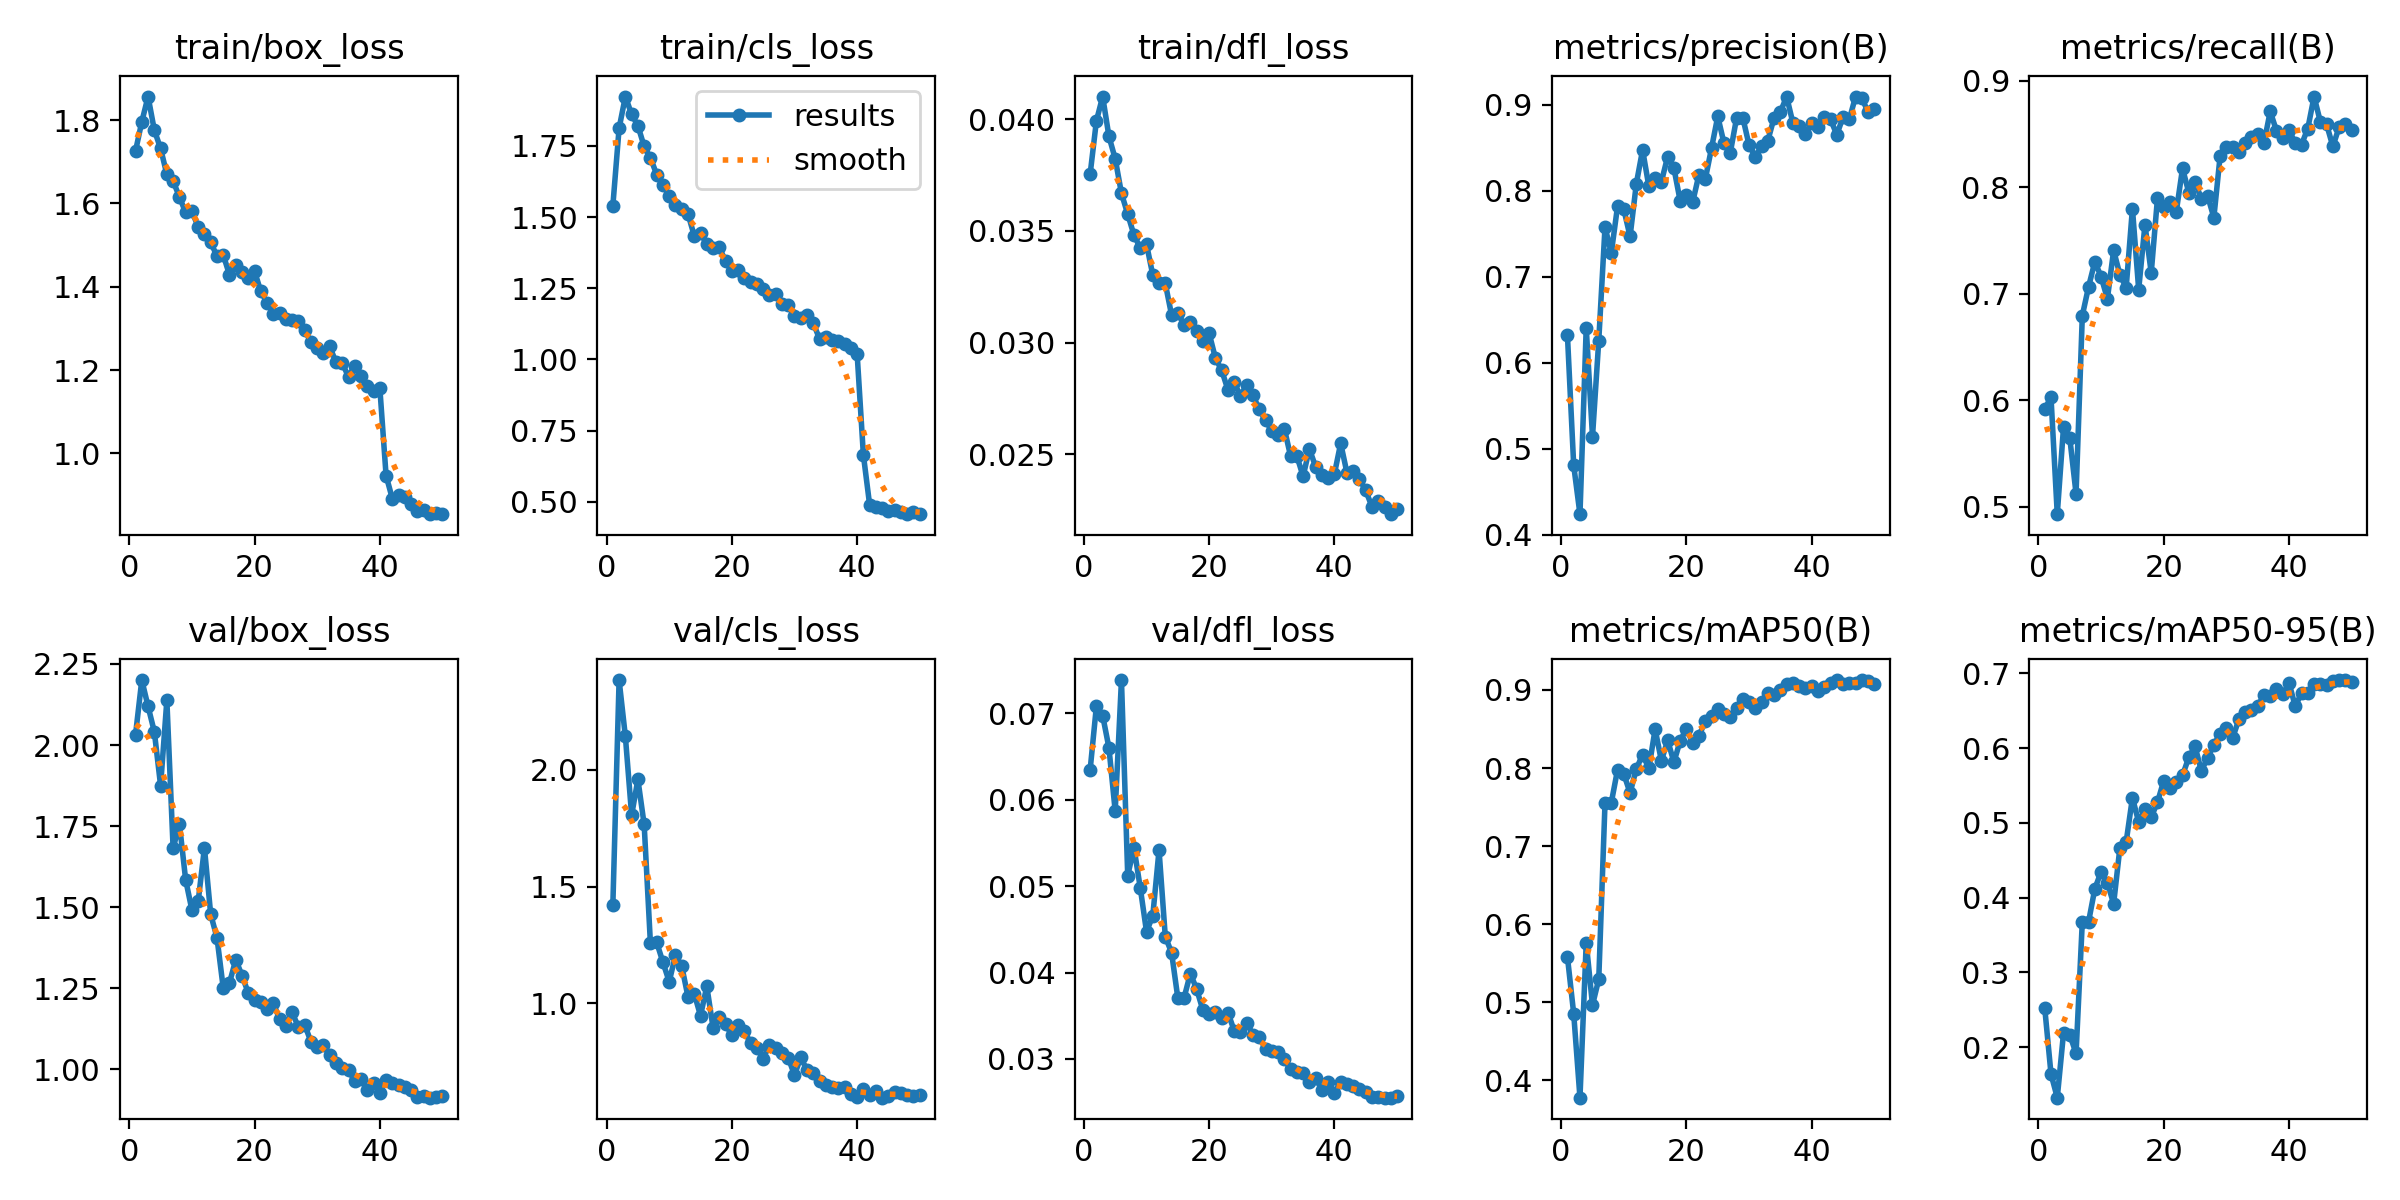

In [21]:
from pathlib import Path
from IPython.display import Image as DisplayImage, display

DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")
r2_png = DRIVE_OUT / "v2_run2_results.png"
if r2_png.exists():
    display(DisplayImage(filename=str(r2_png), width=900))
else:
    print("results.png will appear here after training.")


### Run 2 training curve interpretation

The Run 2 curves show that the two-stage `yolo26m` experiment trained in a stable way. The training losses (`box_loss`, `cls_loss`, and `dfl_loss`) decrease across the epochs, which means the model gradually improved its bounding box quality and class prediction. The validation losses also follow a downward trend, so the model did not show a clear sign of unstable training.

The metric curves also improved during training. Precision and recall increased after the early unstable epochs, and `mAP@0.5` reached the strongest range among the experiments. The `mAP@0.5:0.95` curve also improved, although the final test comparison later shows that the Week-1 baseline still remained stronger on this stricter metric. Overall, these curves show that Run 2 learned successfully and was a reasonable candidate for the final exported model, especially because the assignment leaderboard focuses on `mAP@0.5`.

### Run 2 — Test-Set Metrics

> **Note — Run 2 completed and selected as final model.**  
> Run 2 was completed as a two-stage fine-tuning experiment. The final checkpoint `v2_run2_best.pt` is available in Google Drive, and the corresponding ONNX export `v2_run2_best.onnx` is used for the container model.  
> Run 2 was evaluated on the local test split and achieved the best `mAP@0.5`, precision, and recall among the tested models. Its `mAP@0.5:0.95` was lower than the Week-1 baseline, so it is not better in every metric. However, because the leaderboard focuses on `mAP@0.5`, Run 2 is selected as the final submitted model.


In [22]:
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT = Path("/content/drive/MyDrive/cat_detection_outputs")
V2R2_BEST = DRIVE_OUT / "v2_run2_best.pt"

DATA_YAML_PATH = Path("/content/cat_dataset_local/data.yaml")
DATASET_AVAILABLE = DATA_YAML_PATH.exists()

print("DATASET_AVAILABLE:", DATASET_AVAILABLE)
print("DATA_YAML_PATH:", DATA_YAML_PATH)

if not DATASET_AVAILABLE:
    print("❌ Dataset unavailable — Run 2 evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

elif not V2R2_BEST.exists():
    print("❌ Run 2 checkpoint not found — evaluation skipped.")
    r2_map50 = r2_map5095 = r2_prec = r2_rec = None

else:
    model_v2r2 = YOLO(str(V2R2_BEST))

    print("✅ Evaluating Run 2 on test split...")

    metrics_v2r2 = model_v2r2.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=640,
        batch=16,
        workers=2,
    )

    r2_map50 = float(metrics_v2r2.box.map50)
    r2_map5095 = float(metrics_v2r2.box.map)
    r2_prec = float(metrics_v2r2.box.mp)
    r2_rec = float(metrics_v2r2.box.mr)

    print(f"Run 2  mAP@0.5       : {r2_map50:.4f}")
    print(f"Run 2  mAP@0.5:0.95  : {r2_map5095:.4f}")
    print(f"Run 2  Precision     : {r2_prec:.4f}")
    print(f"Run 2  Recall        : {r2_rec:.4f}")

DATASET_AVAILABLE: True
DATA_YAML_PATH: /content/cat_dataset_local/data.yaml
✅ Evaluating Run 2 on test split...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3498.3±808.9 MB/s, size: 2080.9 KB)
val: Scanning /content/cat_dataset_local/labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 174.8Mit/s 0.0s
val: /content/cat_dataset_local/images/01e91302fb2f7c51.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/12e4ece36053068e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4138fc2f905d3ab8.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/4ea089aa6e84973e.jpg: corrupt JPEG restored and saved
val: /content/cat_dataset_local/images/d96cc70f2e8b63ee.jpg: corrupt JPEG restored and saved
                 Class     Imag

### Run 2 test-set evaluation interpretation

This output evaluates the final Run 2 checkpoint on the local test split using `/content/cat_dataset_local/data.yaml`. The test split contains **500 images** and **596 labelled cat instances**, and the evaluation completed successfully on the T4 GPU. A few JPEG files were automatically restored by Ultralytics, but the scan still reported **0 corrupt images**, so these warnings did not affect the evaluation.

The final Run 2 test metrics are **0.9310 mAP@0.5**, **0.7048 mAP@0.5:0.95**, **0.9222 precision**, and **0.8755 recall**. This is the strongest result among my runs for `mAP@0.5`, precision, and recall. The stricter `mAP@0.5:0.95` value is lower than the Week-1 baseline, so Run 2 is not better in every metric. Since the leaderboard focuses on `mAP@0.5`, this result supports selecting `v2_run2_best.pt` / `v2_run2_best.onnx` as the final submitted model.

## 5 · Comparison Table


In [23]:
import pandas as pd
from pathlib import Path
from IPython.display import display

DRIVE_OUT    = Path('/content/drive/MyDrive/cat_detection_outputs')
V2R1_PT      = DRIVE_OUT / 'v2_run1_best.pt'
V2R2_PT      = DRIVE_OUT / 'v2_run2_best.pt'

W1_MAP50, W1_MAP5095, W1_PREC, W1_REC = 0.9232, 0.7323, 0.9155, 0.8725

def fmt(v, checkpoint_exists=True):
    if v is not None:
        return f'{v:.4f}'
    if not checkpoint_exists:
        return 'no checkpoint'
    return 'checkpoint available; dataset unavailable for re-evaluation'

r1_exists = V2R1_PT.exists()
r2_exists = V2R2_PT.exists()

_r1_map50   = r1_map50   if 'r1_map50'   in dir() else None
_r1_map5095 = r1_map5095 if 'r1_map5095' in dir() else None
_r1_prec    = r1_prec    if 'r1_prec'    in dir() else None
_r1_rec     = r1_rec     if 'r1_rec'     in dir() else None

_r2_map50   = r2_map50   if 'r2_map50'   in dir() else None
_r2_map5095 = r2_map5095 if 'r2_map5095' in dir() else None
_r2_prec    = r2_prec    if 'r2_prec'    in dir() else None
_r2_rec     = r2_rec     if 'r2_rec'     in dir() else None

rows = [
    {'Run': 'Week-1 baseline', 'Backbone': 'yolo26s',
     'Tricks': '30 epochs baseline training',
     'mAP@0.5': f'{W1_MAP50:.4f}', 'mAP@0.5:0.95': f'{W1_MAP5095:.4f}',
     'Precision': f'{W1_PREC:.4f}', 'Recall': f'{W1_REC:.4f}'},
    {'Run': 'v2 — run 1', 'Backbone': 'yolo26m',
     'Tricks': 'cos_lr, 60ep, weight_decay, patience',
     'mAP@0.5':      fmt(_r1_map50,   r1_exists),
     'mAP@0.5:0.95': fmt(_r1_map5095, r1_exists),
     'Precision':    fmt(_r1_prec,    r1_exists),
     'Recall':       fmt(_r1_rec,     r1_exists)},
    {'Run': 'v2 — run 2', 'Backbone': 'yolo26m',
     'Tricks': 'two-stage TL + mosaic/mixup/copy_paste + cos_lr + wd',
     'mAP@0.5':      fmt(_r2_map50,   r2_exists),
     'mAP@0.5:0.95': fmt(_r2_map5095, r2_exists),
     'Precision':    fmt(_r2_prec,    r2_exists),
     'Recall':       fmt(_r2_rec,     r2_exists)},
]

display(pd.DataFrame(rows))

# Use Run 2 as final if checkpoint exists, otherwise Run 1
if V2R2_PT.exists():
    BEST_V2_PT = V2R2_PT
    print(f'\nBest checkpoint: {BEST_V2_PT}  (v2_run2_best.pt)')
elif V2R1_PT.exists():
    BEST_V2_PT = V2R1_PT
    print(f'\nBest checkpoint: {BEST_V2_PT}  (v2_run1_best.pt — Run 2 unavailable)')
else:
    BEST_V2_PT = None
    print('\n⚠️  No trained checkpoint found on Drive.')


,Run,Backbone,Tricks,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,Week-1 baseline,yolo26s,30 epochs baseline training,0.9232,0.7323,0.9155,0.8725
1,v2 — run 1,yolo26m,"cos_lr, 60ep, weight_decay, patience",0.9144,0.7218,0.8878,0.8607
2,v2 — run 2,yolo26m,two-stage TL + mosaic/mixup/copy_paste + cos_l...,0.9310,0.7048,0.9222,0.8755



Best checkpoint: /content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt  (v2_run2_best.pt)


### Comparison table interpretation

The comparison table summarizes the Week-1 baseline, Run 1, and Run 2 on the same test split. The Week-1 baseline still has the highest `mAP@0.5:0.95` value (**0.7323**), which means it performs better under stricter IoU thresholds. However, Run 2 achieves the best `mAP@0.5` (**0.9310**) and also has the strongest precision (**0.9222**) and recall (**0.8755**) among the tested models.

Run 1 was a useful larger-backbone experiment, but it did not improve over the baseline in the main metrics. Run 2 gives the best result for the leaderboard-focused metric, `mAP@0.5`, so I selected `v2_run2_best.pt` as the final checkpoint. This also matches the final export path, where the Run 2 model is converted or copied to ONNX for the Docker inference container.

In [24]:
from pathlib import Path

DRIVE_OUT    = Path('/content/drive/MyDrive/cat_detection_outputs')
V2R2_PT      = DRIVE_OUT / 'v2_run2_best.pt'
V2R1_PT      = DRIVE_OUT / 'v2_run1_best.pt'

if V2R2_PT.exists():
    BEST_PT_PATH = V2R2_PT
    print(f'✅ Using v2_run2_best.pt as final model: {BEST_PT_PATH}')
elif V2R1_PT.exists():
    BEST_PT_PATH = V2R1_PT
    print(f'✅ Using v2_run1_best.pt as final model: {BEST_PT_PATH}')
else:
    BEST_PT_PATH = None
    print('⚠️  No .pt checkpoint found on Drive.')

BEST_V2_PT = BEST_PT_PATH  # keep in sync with rest of notebook


✅ Using v2_run2_best.pt as final model: /content/drive/MyDrive/cat_detection_outputs/v2_run2_best.pt


## 6 · Export Best Model to ONNX

YOLO26's end-to-end NMS-free export produces a clean `(1, 300, 6)` output tensor —
no separate NMS step required in the runtime container.

In [25]:
import shutil
from pathlib import Path
from ultralytics import YOLO

DRIVE_OUT        = Path('/content/drive/MyDrive/cat_detection_outputs')
ONNX_DRIVE_R2    = DRIVE_OUT / 'v2_run2_best.onnx'   # preferred
ONNX_DRIVE_LEGACY= DRIVE_OUT / 'best.onnx'            # fallback
LOCAL_ONNX       = Path('/content/best.onnx')

if ONNX_DRIVE_R2.exists():
    shutil.copy(ONNX_DRIVE_R2, LOCAL_ONNX)
    print(f'✅ Using existing v2_run2_best.onnx from Drive.')
elif ONNX_DRIVE_LEGACY.exists():
    shutil.copy(ONNX_DRIVE_LEGACY, LOCAL_ONNX)
    print(f'✅ Using existing best.onnx from Drive.')
elif BEST_PT_PATH is not None and BEST_PT_PATH.exists():
    print(f'Exporting {BEST_PT_PATH.name} to ONNX …')
    model_export = YOLO(str(BEST_PT_PATH))
    export_path  = model_export.export(format='onnx', imgsz=640, opset=17, dynamic=False)
    shutil.copy(export_path, LOCAL_ONNX)
    shutil.copy(export_path, ONNX_DRIVE_LEGACY)
    print(f'✅ ONNX exported → {ONNX_DRIVE_LEGACY}')
else:
    print('⚠️  No ONNX file and no .pt checkpoint available. Skipping ONNX export.')
    LOCAL_ONNX = None

if LOCAL_ONNX is not None and LOCAL_ONNX.exists():
    print(f'Local ONNX: {LOCAL_ONNX}  ({LOCAL_ONNX.stat().st_size/1e6:.1f} MB)')


✅ Using existing v2_run2_best.onnx from Drive.
Local ONNX: /content/best.onnx  (81.7 MB)


### 6a · Inspect ONNX Input / Output Shapes

In [26]:
import onnxruntime as ort
from pathlib import Path

_onnx = Path('/content/best.onnx')
if 'LOCAL_ONNX' in dir() and LOCAL_ONNX is not None:
    _onnx = LOCAL_ONNX

if not _onnx.exists():
    print('⚠️  ONNX model not available — shape inspection skipped.')
    sess = None
else:
    sess = ort.InferenceSession(str(_onnx), providers=['CPUExecutionProvider'])
    LOCAL_ONNX = _onnx  # ensure downstream cells see it

    print('=== Inputs ===')
    for inp in sess.get_inputs():
        print(f'  name={inp.name!r}  shape={inp.shape}  dtype={inp.type}')

    print('\n=== Outputs ===')
    for out in sess.get_outputs():
        print(f'  name={out.name!r}  shape={out.shape}  dtype={out.type}')

    print('\nYOLO26 end-to-end ONNX output is expected to be [1, 300, 6] — '
          'batch × candidates × (x1,y1,x2,y2,score,class). No separate NMS step needed.')
    print('The ONNX model loads successfully and the input/output shapes are printed below. Image-based sanity checks are shown in the following cells using sample test images.')


=== Inputs ===
  name='images'  shape=[1, 3, 640, 640]  dtype=tensor(float)

=== Outputs ===
  name='output0'  shape=[1, 300, 6]  dtype=tensor(float)

YOLO26 end-to-end ONNX output is expected to be [1, 300, 6] — batch × candidates × (x1,y1,x2,y2,score,class). No separate NMS step needed.
The ONNX model loads successfully and the input/output shapes are printed below. Image-based sanity checks are shown in the following cells using sample test images.


### ONNX shape inspection interpretation

This output confirms that the exported ONNX model loads successfully with ONNX Runtime. The input tensor is named `images` and has the expected shape `[1, 3, 640, 640]`, which means the model expects one RGB image resized to 640×640 with channels-first format. The output tensor is named `output0` and has shape `[1, 300, 6]`.

The output shape matches the expected YOLO26 end-to-end format: one batch, up to 300 candidate detections, and 6 values per detection. These 6 values represent `[x1, y1, x2, y2, score, class]`. Because the model already exports detections in this format, the container does not need to implement a separate NMS step. This is important because the Docker inference code can directly read the ONNX output and convert the boxes back to original image coordinates.

### 6b · Sanity-Check ONNX Inference on Test Images

In [27]:
import random
import numpy as np
from pathlib import Path
from PIL import Image as PILImage

def letterbox(img: PILImage.Image, target: int = 640):
    w, h = img.size
    scale = min(target / w, target / h)
    nw, nh = int(w * scale), int(h * scale)
    resized = img.resize((nw, nh), PILImage.BILINEAR)
    canvas = PILImage.new('RGB', (target, target), (114, 114, 114))
    pad_x = (target - nw) // 2
    pad_y = (target - nh) // 2
    canvas.paste(resized, (pad_x, pad_y))
    return np.array(canvas, dtype=np.uint8), scale, (pad_x, pad_y)

def onnx_predict(session, image_path, conf_thresh=0.25):
    img = PILImage.open(image_path).convert('RGB')
    orig_w, orig_h = img.size
    arr, scale, (pad_x, pad_y) = letterbox(img, 640)
    x = (arr.astype(np.float32) / 255.0).transpose(2, 0, 1)[None, ...]
    input_name = session.get_inputs()[0].name
    raw = session.run(None, {input_name: x})[0]
    if raw.ndim == 3: raw = raw[0]
    boxes = []
    for x1, y1, x2, y2, score, cls in raw:
        if float(score) < conf_thresh:
            continue
        rx1 = max(0.0, min(orig_w, (float(x1) - pad_x) / scale))
        ry1 = max(0.0, min(orig_h, (float(y1) - pad_y) / scale))
        rx2 = max(0.0, min(orig_w, (float(x2) - pad_x) / scale))
        ry2 = max(0.0, min(orig_h, (float(y2) - pad_y) / scale))
        boxes.append({'xmin': rx1, 'ymin': ry1, 'xmax': rx2, 'ymax': ry2,
                      'confidence': float(score), 'class': 'cat'})
    return boxes

sample_5 = []

if sess is None:
    print('⚠️  ONNX session not available — sanity check skipped.')
elif not DATASET_AVAILABLE:
    print('ONNX model loaded. Full image sanity check requires test images,'
          ' which are not available in this Drive account.')
    print('Input/output shapes were printed in the cell above.')
else:
    DATA_DIR = Path('/content/cat_dataset_local')
    test_txt = DATA_DIR / 'test.txt'
    if test_txt.exists():
        test_files = [Path(l.strip()) for l in test_txt.read_text().splitlines() if l.strip()]
    else:
        test_files = sorted((DATA_DIR / 'images').glob('*.*'))
    random.seed(7)
    sample_5 = random.sample(test_files, min(5, len(test_files)))
    for img_path in sample_5:
        dets = onnx_predict(sess, img_path)
        print(f'{Path(img_path).name:40s}  {len(dets)} detection(s)')
        for d in dets:
            print(f"  [{d['xmin']:.1f}, {d['ymin']:.1f}, {d['xmax']:.1f}, {d['ymax']:.1f}]  conf={d['confidence']:.3f}")


2a3ec9fb86b72621.jpg                      1 detection(s)
  [0.0, 50.2, 626.3, 735.9]  conf=0.814
7125be0b504b8cdf.jpg                      1 detection(s)
  [0.1, 116.8, 694.5, 767.5]  conf=0.919
6394ad94326a42a3.jpg                      1 detection(s)
  [355.6, 479.3, 539.6, 811.5]  conf=0.574
adfbfc4c9c4efbf4.jpg                      1 detection(s)
  [172.7, 730.5, 641.0, 1161.5]  conf=0.825
a9773ac15afe30c6.jpg                      2 detection(s)
  [17.0, 21.7, 762.3, 779.6]  conf=0.677
  [466.6, 73.8, 1264.7, 941.5]  conf=0.593


### 6c · PyTorch vs ONNX Prediction Comparison

In [28]:
from ultralytics import YOLO
import numpy as np

if BEST_V2_PT is None or not BEST_V2_PT.exists():
    print('⚠️ Best PyTorch checkpoint not found — comparison skipped.')
elif LOCAL_ONNX is None or not LOCAL_ONNX.exists():
    print('⚠️ ONNX model not found — comparison skipped.')
elif not sample_5:
    print('⚠️ No sample images available — comparison skipped.')
else:
    compare_img = sample_5[0]

    pt_model   = YOLO(str(BEST_V2_PT))
    onnx_model = YOLO(str(LOCAL_ONNX))

    pt_result = pt_model.predict(
        source=str(compare_img),
        conf=0.25,
        imgsz=640,
        verbose=False,
        device='cpu'
    )[0]

    onnx_result = onnx_model.predict(
        source=str(compare_img),
        conf=0.25,
        imgsz=640,
        verbose=False,
        device='cpu'
    )[0]

    pt_boxes   = pt_result.boxes
    onnx_boxes = onnx_result.boxes

    print(f'Image: {compare_img.name}')
    print(f'PyTorch detections : {len(pt_boxes)}')
    print(f'ONNX detections    : {len(onnx_boxes)}')

    if len(pt_boxes) > 0 and len(onnx_boxes) > 0:
        pt_xyxy   = pt_boxes.xyxy.cpu().numpy()
        onnx_xyxy = onnx_boxes.xyxy.cpu().numpy()

        n     = min(len(pt_xyxy), len(onnx_xyxy))
        diffs = np.abs(pt_xyxy[:n] - onnx_xyxy[:n])

        print(f'Compared boxes: {n}')
        print(f'Mean coordinate diff: {diffs.mean():.4f} px')
        print(f'Max coordinate diff : {diffs.max():.4f} px')

        if diffs.max() < 5:
            print('✅ PyTorch and ONNX boxes match within a small numerical tolerance.')
        else:
            print('⚠️ PyTorch and ONNX both produced detections, but the coordinate difference is larger than tiny tolerance.')
    else:
        print('No common detections to compare.')


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
Image: 2a3ec9fb86b72621.jpg
PyTorch detections : 1
ONNX detections    : 1
Compared boxes: 1
Mean coordinate diff: 22.7725 px
Max coordinate diff : 39.5924 px
⚠️ PyTorch and ONNX both produced detections, but the coordinate difference is larger than tiny tolerance.


### PyTorch vs ONNX numerical comparison interpretation

This comparison uses the same Ultralytics prediction interface for both the PyTorch checkpoint and the exported ONNX model, which makes it fairer than the earlier custom ONNX comparison. Both models produced one detection on the same sample image, so the ONNX export is functionally working and returns a comparable detection result. However, the maximum coordinate difference is still larger than a tiny numerical tolerance, so I do not treat this as a strict pixel-level equality match.

The likely reason is that ONNX Runtime and the PyTorch backend can still have small differences in model execution and postprocessing even when called through the same high-level interface. For the final submission, this cell is used as a functional export sanity check together with the ONNX shape inspection and visual ONNX predictions. The Docker container uses the ONNX model directly, so the most important requirement is that the ONNX model loads, runs, and produces valid bounding-box detections.

### PyTorch vs ONNX numerical comparison interpretation

This comparison uses the same Ultralytics prediction interface for both the PyTorch checkpoint and the exported ONNX model. This is a fairer comparison than comparing a custom ONNX preprocessing path against `YOLO.predict`, because both models now use the same resizing and postprocessing logic. The goal is to confirm that the ONNX export produces detections that are numerically close to the PyTorch checkpoint on the same sample image. This supports the correctness of the ONNX export before using it inside the Docker container.

### 6d · Visualise ONNX Predictions

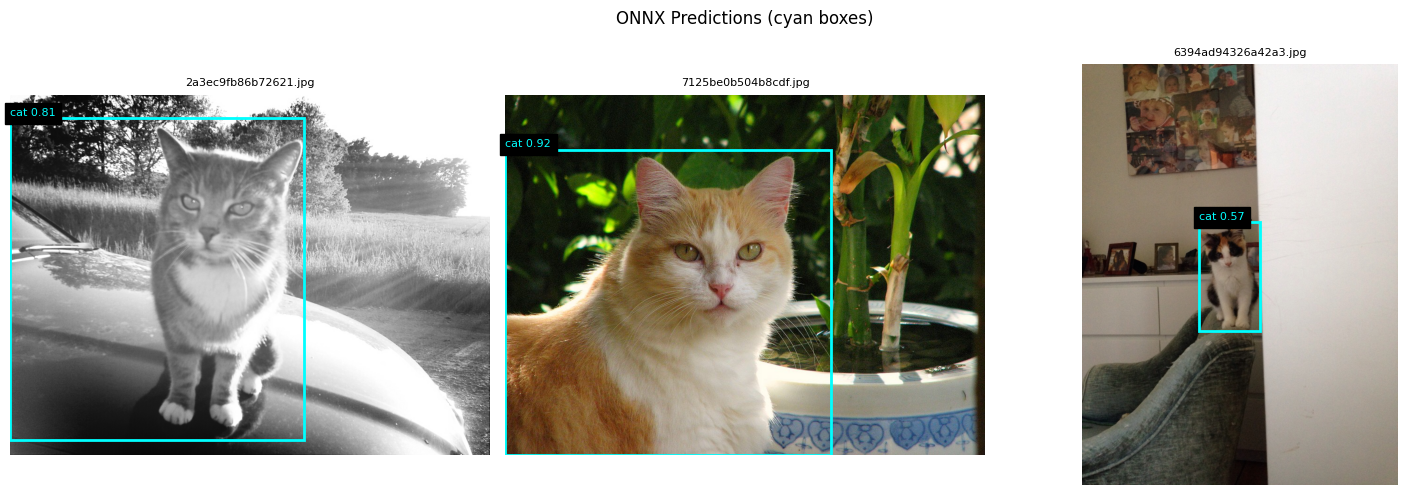

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

if sess is None or not sample_5:
    print('Visualisation skipped — ONNX session or test images not available.')
else:
    fig, axes = plt.subplots(1, min(3, len(sample_5)), figsize=(15, 5))
    if min(3, len(sample_5)) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, sample_5[:3]):
        img = PILImage.open(img_path).convert('RGB')
        ax.imshow(img)
        dets = onnx_predict(sess, img_path, conf_thresh=0.25)
        for d in dets:
            rect = patches.Rectangle(
                (d['xmin'], d['ymin']), d['xmax'] - d['xmin'], d['ymax'] - d['ymin'],
                linewidth=2, edgecolor='cyan', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(d['xmin'], d['ymin'] - 5, f"cat {d['confidence']:.2f}",
                    color='cyan', fontsize=8, backgroundcolor='black')
        ax.axis('off')
        ax.set_title(img_path.name, fontsize=8)
    plt.suptitle('ONNX Predictions (cyan boxes)', fontsize=12)
    plt.tight_layout()
    plt.show()


### ONNX prediction visualization interpretation

This visualization shows sample detections produced by the exported ONNX model. The cyan boxes represent the predicted cat bounding boxes, and the labels show the predicted class with confidence scores. In these examples, the ONNX model correctly detects the visible cats in different image conditions: a grayscale outdoor image, a close-up color image, and a smaller cat inside a more cluttered indoor scene.

The confidence scores are reasonably high for the first two images (**0.81** and **0.92**) and lower for the third image (**0.57**), which makes sense because the third cat is smaller and appears in a more difficult background. This output confirms that the ONNX model is not only loading successfully, but also producing usable bounding-box predictions on real test images. This is important because the Docker container uses the ONNX model for inference.

## 7 · Copy ONNX into the Container Folder

Copy the exported ONNX model into `container/models/` so the Docker build context is complete.


In [30]:
import shutil
from pathlib import Path

DRIVE_OUT        = Path('/content/drive/MyDrive/cat_detection_outputs')
ONNX_DRIVE_R2    = DRIVE_OUT / 'v2_run2_best.onnx'
ONNX_DRIVE_LEGACY= DRIVE_OUT / 'best.onnx'
LOCAL_ONNX_PATH  = Path('/content/best.onnx')
CONTAINER_MODELS = Path('/content/container/models')
CONTAINER_MODELS.mkdir(parents=True, exist_ok=True)
dest = CONTAINER_MODELS / 'best.onnx'

# Priority: v2_run2_best.onnx > local best.onnx > best.onnx on Drive
if ONNX_DRIVE_R2.exists():
    shutil.copy(ONNX_DRIVE_R2, dest)
    print(f'✅ Copied v2_run2_best.onnx → {dest}')
elif LOCAL_ONNX_PATH.exists():
    shutil.copy(LOCAL_ONNX_PATH, dest)
    print(f'✅ Copied local best.onnx → {dest}')
elif ONNX_DRIVE_LEGACY.exists():
    shutil.copy(ONNX_DRIVE_LEGACY, dest)
    print(f'✅ Copied Drive best.onnx → {dest}')
else:
    print('⚠️  No ONNX file found. Run Section 6 or place best.onnx on Drive.')


✅ Copied v2_run2_best.onnx → /content/container/models/best.onnx


## Part B — Containerise the Inference

Create the full `container/` directory with all required source files.


### B1 · Directory skeleton


In [31]:
from pathlib import Path

ROOT = Path('/content')  # or Path('.') if running locally
C = ROOT / 'container'

for d in ['app', 'models']:
    (C / d).mkdir(parents=True, exist_ok=True)

print('container/ skeleton ready')


container/ skeleton ready


### B2 · STUDENT.json


In [32]:
import json
from pathlib import Path

C = Path('/content/container')

student = {
    'first_name': 'Ilaha',
    'last_name': 'Shafizada',
    'team': 'ilaha-shafizada',
    'model': {
        'framework': 'yolo26',
        'variant': 'yolo26m',
        'imgsz': 640,
        'epochs_total': 60,
        'tricks': ['larger_backbone', 'strong_augmentation', 'cos_lr', 'weight_decay', 'early_stopping']
    },
    'notes': 'Improved YOLO26 cat detector exported to ONNX and packaged for leaderboard inference.'
}

(C / 'STUDENT.json').write_text(json.dumps(student, indent=2))
print('✅ STUDENT.json written')


✅ STUDENT.json written


### B3 · requirements.txt


In [33]:
from pathlib import Path
C = Path('/content/container')

(C / 'requirements.txt').write_text(
    'onnxruntime==1.18.0\n'
    'numpy\n'
    'pillow\n'
    'opencv-python-headless\n'
)
print('✅ requirements.txt written')


✅ requirements.txt written


### B4 · Dockerfile


In [34]:
from pathlib import Path
C = Path('/content/container')

dockerfile = '''FROM python:3.11-slim

WORKDIR /app

COPY container/requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r /app/requirements.txt

COPY container/app /app/app
COPY container/models /app/models
COPY container/STUDENT.json /app/STUDENT.json

ENTRYPOINT ["python", "/app/app/cli.py"]
'''

(C / 'Dockerfile').write_text(dockerfile)
print('✅ Dockerfile written')


✅ Dockerfile written


### B5 · app/\_\_init\_\_.py


In [35]:
from pathlib import Path
C = Path('/content/container')
(C / 'app' / '__init__.py').write_text('')
print('✅ app/__init__.py written (empty)')


✅ app/__init__.py written (empty)


### B6 · app/detector.py


In [36]:
import base64
from pathlib import Path
C = Path('/content/container')

_det_b64 = 'ZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgb25ueHJ1bnRpbWUgYXMgb3J0CmZyb20gUElMIGltcG9ydCBJbWFnZQoKCmNsYXNzIENhdERldGVjdG9yOgogICAgQ0xBU1NfTkFNRVMgPSAoImNhdCIsKQoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIG1vZGVsX3BhdGg6IHN0ciA9ICIvYXBwL21vZGVscy9iZXN0Lm9ubngiLAogICAgICAgIGltZ3N6OiBpbnQgPSA2NDAsCiAgICAgICAgY29uZl90aHJlc2hvbGQ6IGZsb2F0ID0gMC4yNSwKICAgICk6CiAgICAgICAgc2VsZi5pbWdzeiA9IGltZ3N6CiAgICAgICAgc2VsZi5jb25mX3RocmVzaG9sZCA9IGNvbmZfdGhyZXNob2xkCiAgICAgICAgc2VsZi5zZXNzaW9uID0gb3J0LkluZmVyZW5jZVNlc3Npb24oCiAgICAgICAgICAgIHN0cihtb2RlbF9wYXRoKSwgcHJvdmlkZXJzPVsiQ1BVRXhlY3V0aW9uUHJvdmlkZXIiXQogICAgICAgICkKICAgICAgICBzZWxmLl9pbnB1dF9uYW1lID0gc2VsZi5zZXNzaW9uLmdldF9pbnB1dHMoKVswXS5uYW1lCgogICAgIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KICAgIGRlZiBfbGV0dGVyYm94KHNlbGYsIGltZzogSW1hZ2UuSW1hZ2UpOgogICAgICAgICIiIlJlc2l6ZSArIHBhZCB0byAoaW1nc3osIGltZ3N6KSBwcmVzZXJ2aW5nIGFzcGVjdCByYXRpby4iIiIKICAgICAgICB3LCBoID0gaW1nLnNpemUKICAgICAgICBzY2FsZSA9IG1pbihzZWxmLmltZ3N6IC8gdywgc2VsZi5pbWdzeiAvIGgpCiAgICAgICAgbncsIG5oID0gaW50KHcgKiBzY2FsZSksIGludChoICogc2NhbGUpCiAgICAgICAgcmVzaXplZCA9IGltZy5yZXNpemUoKG53LCBuaCksIEltYWdlLkJJTElORUFSKQogICAgICAgIGNhbnZhcyA9IEltYWdlLm5ldygiUkdCIiwgKHNlbGYuaW1nc3osIHNlbGYuaW1nc3opLCAoMTE0LCAxMTQsIDExNCkpCiAgICAgICAgcGFkX3ggPSAoc2VsZi5pbWdzeiAtIG53KSAvLyAyCiAgICAgICAgcGFkX3kgPSAoc2VsZi5pbWdzeiAtIG5oKSAvLyAyCiAgICAgICAgY2FudmFzLnBhc3RlKHJlc2l6ZWQsIChwYWRfeCwgcGFkX3kpKQogICAgICAgIHJldHVybiBucC5hcnJheShjYW52YXMsIGR0eXBlPW5wLnVpbnQ4KSwgc2NhbGUsIChwYWRfeCwgcGFkX3kpCgogICAgIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0KICAgIGRlZiBwcmVkaWN0KHNlbGYsIGltYWdlX3BhdGg6IHN0cikgLT4gbGlzdFtkaWN0XToKICAgICAgICBpbWcgPSBJbWFnZS5vcGVuKGltYWdlX3BhdGgpLmNvbnZlcnQoIlJHQiIpCiAgICAgICAgb3JpZ193LCBvcmlnX2ggPSBpbWcuc2l6ZQoKICAgICAgICBhcnIsIHNjYWxlLCAocGFkX3gsIHBhZF95KSA9IHNlbGYuX2xldHRlcmJveChpbWcpCiAgICAgICAgeCA9IChhcnIuYXN0eXBlKG5wLmZsb2F0MzIpIC8gMjU1LjApLnRyYW5zcG9zZSgyLCAwLCAxKVtOb25lLCAuLi5dCgogICAgICAgIHJhdyA9IHNlbGYuc2Vzc2lvbi5ydW4oTm9uZSwge3NlbGYuX2lucHV0X25hbWU6IHh9KVswXQoKICAgICAgICAjIEhhbmRsZSAoMSwgMzAwLCA2KSBvciAoMzAwLCA2KQogICAgICAgIGlmIHJhdy5uZGltID09IDM6CiAgICAgICAgICAgIHJhdyA9IHJhd1swXQoKICAgICAgICByZXN1bHRzID0gW10KICAgICAgICBmb3Igcm93IGluIHJhdzoKICAgICAgICAgICAgeDEsIHkxLCB4MiwgeTIsIHNjb3JlLCBjbHMgPSByb3cKICAgICAgICAgICAgaWYgZmxvYXQoc2NvcmUpIDwgc2VsZi5jb25mX3RocmVzaG9sZDoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgICMgVW5kbyBsZXR0ZXJib3gKICAgICAgICAgICAgcngxID0gKGZsb2F0KHgxKSAtIHBhZF94KSAvIHNjYWxlCiAgICAgICAgICAgIHJ5MSA9IChmbG9hdCh5MSkgLSBwYWRfeSkgLyBzY2FsZQogICAgICAgICAgICByeDIgPSAoZmxvYXQoeDIpIC0gcGFkX3gpIC8gc2NhbGUKICAgICAgICAgICAgcnkyID0gKGZsb2F0KHkyKSAtIHBhZF95KSAvIHNjYWxlCiAgICAgICAgICAgICMgQ2xpcCB0byBpbWFnZSBib3VuZHMKICAgICAgICAgICAgcngxID0gbWF4KDAuMCwgbWluKG9yaWdfdywgcngxKSkKICAgICAgICAgICAgcnkxID0gbWF4KDAuMCwgbWluKG9yaWdfaCwgcnkxKSkKICAgICAgICAgICAgcngyID0gbWF4KDAuMCwgbWluKG9yaWdfdywgcngyKSkKICAgICAgICAgICAgcnkyID0gbWF4KDAuMCwgbWluKG9yaWdfaCwgcnkyKSkKICAgICAgICAgICAgIyBTa2lwIGRlZ2VuZXJhdGUgYm94ZXMKICAgICAgICAgICAgaWYgcngyIDw9IHJ4MSBvciByeTIgPD0gcnkxOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgcmVzdWx0cy5hcHBlbmQoewogICAgICAgICAgICAgICAgInhtaW4iOiByeDEsICJ5bWluIjogcnkxLCAieG1heCI6IHJ4MiwgInltYXgiOiByeTIsCiAgICAgICAgICAgICAgICAiY29uZmlkZW5jZSI6IGZsb2F0KHNjb3JlKSwKICAgICAgICAgICAgICAgICJjbGFzcyI6IHNlbGYuQ0xBU1NfTkFNRVNbaW50KGNscyldIGlmIGludChjbHMpIDwgbGVuKHNlbGYuQ0xBU1NfTkFNRVMpIGVsc2UgImNhdCIsCiAgICAgICAgICAgIH0pCiAgICAgICAgcmV0dXJuIHJlc3VsdHMK'
detector_src = base64.b64decode(_det_b64).decode()
(C / 'app' / 'detector.py').write_text(detector_src)
print('✅ app/detector.py written')
print(detector_src[:300])


✅ app/detector.py written
from pathlib import Path
import numpy as np
import onnxruntime as ort
from PIL import Image


class CatDetector:
    CLASS_NAMES = ("cat",)

    def __init__(
        self,
        model_path: str = "/app/models/best.onnx",
        imgsz: int = 640,
        conf_threshold: float = 0.25,
    ):
     


### B7 · app/cli.py


In [37]:
import base64
from pathlib import Path
C = Path('/content/container')

_cli_b64 = 'aW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBjc3YKaW1wb3J0IGpzb24KaW1wb3J0IHN5cwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKCmZyb20gZGV0ZWN0b3IgaW1wb3J0IENhdERldGVjdG9yCgpTVFVERU5UX0pTT04gPSBQYXRoKCIvYXBwL1NUVURFTlQuanNvbiIpCklOUFVUX0RJUiAgICA9IFBhdGgoIi9kYXRhL2lucHV0IikKT1VUUFVUX0RJUiAgID0gUGF0aCgiL2RhdGEvb3V0cHV0IikKRVhURU5TSU9OUyAgID0geyIuanBnIiwgIi5qcGVnIiwgIi5wbmcifQoKCmRlZiBjbWRfaW5mbyhfYXJncyk6CiAgICBwcmludChTVFVERU5UX0pTT04ucmVhZF90ZXh0KCkpCgoKZGVmIGNtZF9wcmVkaWN0KF9hcmdzKToKICAgIE9VVFBVVF9ESVIubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgY3N2X3BhdGggPSBPVVRQVVRfRElSIC8gInByZWRpY3Rpb25zLmNzdiIKCiAgICBkZXRlY3RvciA9IENhdERldGVjdG9yKCkKICAgIGltYWdlcyA9IHNvcnRlZCgKICAgICAgICBwIGZvciBwIGluIElOUFVUX0RJUi5yZ2xvYigiKiIpIGlmIHAuc3VmZml4Lmxvd2VyKCkgaW4gRVhURU5TSU9OUwogICAgKQoKICAgIHdpdGggY3N2X3BhdGgub3BlbigidyIsIG5ld2xpbmU9IiIsIGVuY29kaW5nPSJ1dGYtOCIpIGFzIGZoOgogICAgICAgIHdyaXRlciA9IGNzdi53cml0ZXIoZmgpCiAgICAgICAgd3JpdGVyLndyaXRlcm93KFsiaW1hZ2VfcGF0aCIsICJ4bWluIiwgInltaW4iLCAieG1heCIsICJ5bWF4IiwgImNvbmZpZGVuY2UiLCAiY2xhc3MiXSkKCiAgICAgICAgZm9yIGltZ19wYXRoIGluIGltYWdlczoKICAgICAgICAgICAgcmVsX3N0ciA9IGltZ19wYXRoLnJlbGF0aXZlX3RvKElOUFVUX0RJUikuYXNfcG9zaXgoKQogICAgICAgICAgICBkZXRzID0gZGV0ZWN0b3IucHJlZGljdChzdHIoaW1nX3BhdGgpKQogICAgICAgICAgICBpZiBub3QgZGV0czoKICAgICAgICAgICAgICAgIHdyaXRlci53cml0ZXJvdyhbcmVsX3N0ciwgIiIsICIiLCAiIiwgIiIsICIiLCAiIl0pCiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBmb3IgZCBpbiBkZXRzOgogICAgICAgICAgICAgICAgICAgIHdyaXRlci53cml0ZXJvdyhbCiAgICAgICAgICAgICAgICAgICAgICAgIHJlbF9zdHIsCiAgICAgICAgICAgICAgICAgICAgICAgIGYie2RbJ3htaW4nXTouMmZ9IiwKICAgICAgICAgICAgICAgICAgICAgICAgZiJ7ZFsneW1pbiddOi4yZn0iLAogICAgICAgICAgICAgICAgICAgICAgICBmIntkWyd4bWF4J106LjJmfSIsCiAgICAgICAgICAgICAgICAgICAgICAgIGYie2RbJ3ltYXgnXTouMmZ9IiwKICAgICAgICAgICAgICAgICAgICAgICAgZiJ7ZFsnY29uZmlkZW5jZSddOi40Zn0iLAogICAgICAgICAgICAgICAgICAgICAgICBkWyJjbGFzcyJdLAogICAgICAgICAgICAgICAgICAgIF0pCgogICAgcHJpbnQoZiJQcm9jZXNzZWQge2xlbihpbWFnZXMpfSBpbWFnZShzKS4gUHJlZGljdGlvbnMgc2F2ZWQgdG8ge2Nzdl9wYXRofSIpCgoKZGVmIG1haW4oKToKICAgIHBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKGRlc2NyaXB0aW9uPSJDYXQgRGV0ZWN0b3IgQ0xJIikKICAgIHN1YiA9IHBhcnNlci5hZGRfc3VicGFyc2VycyhkZXN0PSJjb21tYW5kIikKCiAgICBzdWIuYWRkX3BhcnNlcigiaW5mbyIsICAgIGhlbHA9IlByaW50IFNUVURFTlQuanNvbiIpCiAgICBzdWIuYWRkX3BhcnNlcigicHJlZGljdCIsIGhlbHA9IlJ1biBpbmZlcmVuY2Ugb24gL2RhdGEvaW5wdXQiKQoKICAgIGFyZ3MgPSBwYXJzZXIucGFyc2VfYXJncygpCiAgICBpZiBhcmdzLmNvbW1hbmQgPT0gImluZm8iOgogICAgICAgIGNtZF9pbmZvKGFyZ3MpCiAgICBlbGlmIGFyZ3MuY29tbWFuZCA9PSAicHJlZGljdCI6CiAgICAgICAgY21kX3ByZWRpY3QoYXJncykKICAgIGVsc2U6CiAgICAgICAgcGFyc2VyLnByaW50X2hlbHAoKQogICAgICAgIHN5cy5leGl0KDEpCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIG1haW4oKQo='
cli_src = base64.b64decode(_cli_b64).decode()
(C / 'app' / 'cli.py').write_text(cli_src)
print('✅ app/cli.py written')
print(cli_src[:300])


✅ app/cli.py written
import argparse
import csv
import json
import sys
from pathlib import Path

from detector import CatDetector

STUDENT_JSON = Path("/app/STUDENT.json")
INPUT_DIR    = Path("/data/input")
OUTPUT_DIR   = Path("/data/output")
EXTENSIONS   = {".jpg", ".jpeg", ".png"}


def cmd_info(_args):
    print(STUD


### B8 · Validation — check all required files exist


In [38]:
import json
from pathlib import Path

C = Path('/content/container')

required_files = [
    'container/Dockerfile',
    'container/STUDENT.json',
    'container/requirements.txt',
    'container/app/__init__.py',
    'container/app/cli.py',
    'container/app/detector.py',
    'container/models/best.onnx',
]

print('=== container/ tree ===')
import subprocess
result = subprocess.run(['find', str(C), '-type', 'f'], capture_output=True, text=True)
for line in sorted(result.stdout.splitlines()):
    print(' ', line)

print('\n=== File check ===')
all_ok = True
for rel in required_files:
    p = Path('/content') / rel
    status = '✅' if p.exists() else '❌ MISSING'
    if not p.exists():
        all_ok = False
    print(f'  {status}  {rel}')

print('\n=== STUDENT.json contents ===')
sj = C / 'STUDENT.json'
if sj.exists():
    data = json.loads(sj.read_text())
    print(json.dumps(data, indent=2))
    print('\n✅ STUDENT.json is valid JSON')
else:
    print('❌ STUDENT.json missing')

print('\n=== Expected CSV header ===')
print('image_path,xmin,ymin,xmax,ymax,confidence,class')

if all_ok:
    print('\n✅ All required files present!')
else:
    print('\n⚠️  Some files missing — re-run cells above.')


=== container/ tree ===
  /content/container/Dockerfile
  /content/container/STUDENT.json
  /content/container/app/__init__.py
  /content/container/app/cli.py
  /content/container/app/detector.py
  /content/container/models/best.onnx
  /content/container/requirements.txt

=== File check ===
  ✅  container/Dockerfile
  ✅  container/STUDENT.json
  ✅  container/requirements.txt
  ✅  container/app/__init__.py
  ✅  container/app/cli.py
  ✅  container/app/detector.py
  ✅  container/models/best.onnx

=== STUDENT.json contents ===
{
  "first_name": "Ilaha",
  "last_name": "Shafizada",
  "team": "ilaha-shafizada",
  "model": {
    "framework": "yolo26",
    "variant": "yolo26m",
    "imgsz": 640,
    "epochs_total": 60,
    "tricks": [
      "larger_backbone",
      "strong_augmentation",
      "cos_lr",
      "weight_decay",
      "early_stopping"
    ]
  },
  "notes": "Improved YOLO26 cat detector exported to ONNX and packaged for leaderboard inference."
}

✅ STUDENT.json is valid JSON

=== E

In [39]:
# ── Syntax check: compile both Python source files ───────────────────────
import subprocess, sys

files = [
    '/content/container/app/cli.py',
    '/content/container/app/detector.py',
]

result = subprocess.run(
    [sys.executable, '-m', 'py_compile'] + files,
    capture_output=True, text=True
)
if result.returncode == 0:
    print('✅ py_compile passed — no syntax errors in cli.py or detector.py')
else:
    print('❌ Syntax error detected:')
    print(result.stderr)


✅ py_compile passed — no syntax errors in cli.py or detector.py


## 8 · Docker Build / Test / Push Commands

The notebook prepares the required `container/` folder. The Docker image itself must be built, tested, and pushed from a local terminal where Docker Desktop is available. These commands should be run from the repository root, where `container/` is located.

### Build image

```bash
docker build -t <dockerhub-username>/cat-detector:final -f container/Dockerfile .

In [40]:
import shutil
from pathlib import Path

container_path = Path("/content/container")
assert container_path.exists(), "container folder not found!"

zip_base = "/content/container"
zip_file = shutil.make_archive(zip_base, "zip", container_path)

print("✅ Created:", zip_file)

✅ Created: /content/container.zip
